In [2]:
import numpy as np
import matplotlib

%matplotlib inline

In [24]:
def fetch(url: str):
    import requests, gzip, os, hashlib, numpy as np

    fp = os.path.join("/tmp", hashlib.md5(url.encode('utf-8')).hexdigest())

    if os.path.isfile(fp):
        with open(fp, 'rb') as f:
            dat = f.read()
    else:
        r = requests.get(
            url.replace("http://", "https://"),
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=10
        )
        r.raise_for_status()
        dat = r.content

        with open(fp, 'wb') as f:
            f.write(dat)

    return np.frombuffer(gzip.decompress(dat), dtype=np.uint8).copy()

In [ ]:
BASE = "https://storage.googleapis.com/cvdf-datasets/mnist/"

X_train = fetch(BASE + "train-images-idx3-ubyte.gz")[0x10:].reshape(-1, 28, 28)
Y_train = fetch(BASE + "train-labels-idx1-ubyte.gz")[8:]
X_test  = fetch(BASE + "t10k-images-idx3-ubyte.gz")[0x10:].reshape(-1, 28, 28)
Y_test  = fetch(BASE + "t10k-labels-idx1-ubyte.gz")[8:]

X_train = X_train / 255.0
X_test = X_test / 255.0

In [21]:
import torch
import torch.nn as nn

In [ ]:
class BobNet(nn.Module):
    def __init__(self):
        super(BobNet, self).__init__()
        self.l1 = nn.Linear(784, 128)
        self.act = nn.ReLU()
        self.l2 = nn.Linear(128, 10)
    def forward(self, x):
        x = self.l1(x)
        x = self.act(x)
        x = self.l2(x)

        return x

model = BobNet()

BS = 32

lossfn = nn.CrossEntropyLoss()

optim = torch.optim.Adam(model.parameters())

losses, accs = [], []

for i in range(1000):
    optim.zero_grad()
    samp = np.random.randint(0, X_train.shape[0], size=(BS))
    X = torch.tensor(X_train[samp].reshape((-1, 28*28))).float()
    Y = torch.tensor(Y_train[samp]).long()

    out = model(X)
    cat = torch.argmax(out, dim=1)
    accuracy = (cat == Y).float().mean()
    loss = lossfn(out, Y)

    loss.backward()

    optim.step()
    loss, accuracy = loss.item(), accuracy.item()
    losses.append(loss)
    accs.append(accuracy)

tensor(0.)
2.3032712936401367
tensor(0.1562)
2.2741332054138184
tensor(0.2188)
2.240664482116699
tensor(0.2812)
2.254641056060791
tensor(0.3125)
2.213221549987793
tensor(0.3125)
2.168992757797241
tensor(0.2500)
2.1634011268615723
tensor(0.4375)
2.0430216789245605
tensor(0.3750)
2.0330114364624023
tensor(0.5000)
2.021307945251465
tensor(0.5312)
1.9799015522003174
tensor(0.4688)
1.9979557991027832
tensor(0.5938)
1.9811617136001587
tensor(0.7500)
1.8729991912841797
tensor(0.7188)
1.7432721853256226
tensor(0.4688)
1.9582644701004028
tensor(0.6562)
1.8147170543670654
tensor(0.5938)
1.839357614517212
tensor(0.8125)
1.6578195095062256
tensor(0.6562)
1.7328928709030151
tensor(0.8125)
1.577988862991333
tensor(0.7188)
1.6506091356277466
tensor(0.7188)
1.5440503358840942
tensor(0.7188)
1.386490821838379
tensor(0.6875)
1.5651392936706543
tensor(0.8750)
1.2760286331176758
tensor(0.5938)
1.5051794052124023
tensor(0.6875)
1.356278419494629
tensor(0.8125)
1.3295111656188965
tensor(0.8438)
1.2759419679

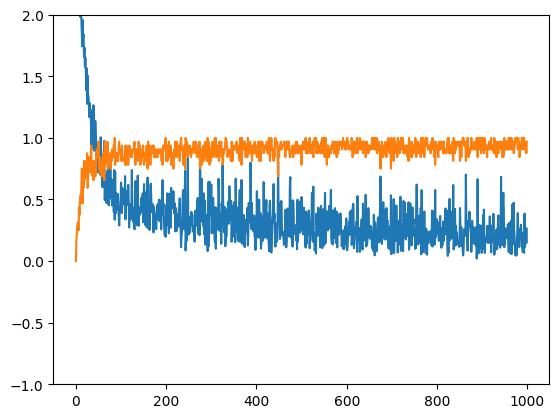

In [77]:
plt.ylim(-1, 2)
plot(losses)
plot(accs)

In [78]:
preds = torch.argmax(model(torch.tensor(X_test).reshape((-1, 28*28)).float()), dim=1).numpy()
(Y_test == preds).mean()

np.float64(0.9331)